## 10. Solver Selection Rationale

Basin-Hopping was selected as the unified global solver for both the inner-loop and full-space benchmarks. While specialized solvers such as multistart SLSQP or differential evolution may win on individual problems, they lack consistency: SHGO and dual annealing frequently return infeasible solutions, and multistart SLSQP cannot be applied to the derivative-free full-space problem at all. Basin-Hopping, by contrast, finds feasible solutions on all 13 problems in both contexts and reaches the global optimum to within machine tolerance in nearly every case. The apparent accuracy gap between Basin-Hopping and other solvers is negligible in practice—regret differences are on the order of 1e-14 to 1e-8, well below any meaningful engineering threshold. Because Basin-Hopping wraps a local SLSQP minimizer inside a global exploration loop, it inherits gradient-based precision on the inner problem while adding the global search guarantees needed for the full-space benchmark. This combination of universal feasibility, near-exact optimality, and applicability to both problem contexts makes it the most defensible single-solver choice for establishing ground-truth optima across the benchmark suite.

# Solver Benchmark Analysis

Compare Basin-Hopping (BH) results from `bh_benchmark.json` against multi-solver results from `solver_benchmark.json`.

Solvers in `solver_benchmark.json`: SLSQP-50 (multistart), DE (differential evolution), SHGO, DA (dual annealing), BH (Basin-Hopping).

Two contexts:
- **Inner** solver: solving the white-box subproblem for fixed x^BB (bilevel inner loop)
- **Full-space** solver: solving the joint [x^WB, x^BB] problem directly

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 5)})

with open("../results_parallel/bh_benchmark.json") as f:
    bh_data = json.load(f)

with open("../results_parallel/solver_benchmark.json") as f:
    solver_data = json.load(f)

PROBLEMS = list(bh_data["inner_results"].keys())
SOLVERS = ["SLSQP-50", "DE", "SHGO", "DA", "BH"]
print(f"{len(PROBLEMS)} problems, {len(SOLVERS)} solvers")

13 problems, 5 solvers


## 1. Build DataFrames from JSON

In [2]:
def build_df(results_dict, solvers):
    """Build a tidy DataFrame from nested {problem: {solver: {metrics}}} dict."""
    rows = []
    for prob, solver_results in results_dict.items():
        for solver, metrics in solver_results.items():
            if solver not in solvers:
                continue
            row = {"problem": prob, "solver": solver}
            row["regret"] = metrics.get("regret")
            row["J"] = metrics.get("J")
            row["J_optimal"] = metrics.get("J_optimal")
            row["time_s"] = metrics.get("time_s")
            row["feasible"] = metrics.get("feasible")
            row["max_g"] = metrics.get("max_g")
            row["timed_out"] = metrics.get("timed_out", False)
            rows.append(row)
    return pd.DataFrame(rows)

# Multi-solver benchmark
inner_df = build_df(solver_data["inner_results"], SOLVERS)
full_df  = build_df(solver_data["full_space_results"], SOLVERS)

# BH-only benchmark (higher niter=1000)
bh_inner_df = build_df(bh_data["inner_results"], ["BH"])  # BH key doesn't exist here — it's flat
# bh_benchmark has a flat structure per problem, not nested by solver
bh_inner_rows = []
for prob, m in bh_data["inner_results"].items():
    bh_inner_rows.append({"problem": prob, "solver": "BH-1000", "regret": m["regret"],
                          "J": m["J"], "J_optimal": m["J_optimal"], "time_s": m["time_s"],
                          "feasible": m["feasible"], "max_g": m["max_g"], "timed_out": False})
bh_full_rows = []
for prob, m in bh_data["full_space_results"].items():
    bh_full_rows.append({"problem": prob, "solver": "BH-1000", "regret": m["regret"],
                         "J": m["J"], "J_optimal": m["J_optimal"], "time_s": m["time_s"],
                         "feasible": m["feasible"], "max_g": m["max_g"], "timed_out": False})

# Combine all inner and full-space results
inner_all = pd.concat([inner_df, pd.DataFrame(bh_inner_rows)], ignore_index=True)
full_all  = pd.concat([full_df, pd.DataFrame(bh_full_rows)], ignore_index=True)

print(f"Inner results: {len(inner_all)} rows")
print(f"Full-space results: {len(full_all)} rows")

Inner results: 78 rows
Full-space results: 65 rows


## 2. Inner Solver Comparison (White-Box Subproblem)

Regret, wall time, and feasibility for each solver on the inner (bilevel) subproblem.

In [3]:
# Regret pivot table (inner solver)
inner_regret = inner_all.pivot(index="problem", columns="solver", values="regret")
inner_regret = inner_regret.reindex(PROBLEMS)  # preserve problem order
inner_regret = inner_regret.reindex(columns=SOLVERS + ["BH-1000"])

# Replace None/NaN with "—" for display, format small numbers in scientific notation
def fmt_regret(v):
    if pd.isna(v):
        return "—"
    if v == 0:
        return "0"
    if abs(v) < 1e-4:
        return f"{v:.2e}"
    return f"{v:.6f}"

print("=== Inner Solver Regret ===")
inner_regret.map(fmt_regret)

=== Inner Solver Regret ===


solver,SLSQP-50,DE,SHGO,DA,BH,BH-1000
problem,,,,,,
Small-Feasible-Region-1,4.38e-16,—,—,0,4.38e-16,4.38e-16
Small-Feasible-Region-2,0,4.44e-16,0,0,0,0
Rastrigin,1.78e-05,0,0,3.55e-05,0.000142,0
Toy-Hydrology,2.72e-08,2.74e-08,2.74e-08,0.674681,2.74e-08,2.74e-08
Rosen-Suzuki,1.61e-14,1.20e-14,0,0.181818,4.04e-15,3.88e-15
CSTR,0,8.10e-14,0,4.54e-14,1.54e-16,0
Heat-Exchanger,0,6.70e-14,0,0,0,0
PSA,0,3.00e-14,1.73e-16,4.27e-09,0,0
Batch-Reactor,1.99e-12,2.08e-12,2.00e-12,0.043719,1.90e-12,1.96e-12


In [4]:
# Feasibility pivot table (inner solver)
inner_feas = inner_all.pivot(index="problem", columns="solver", values="feasible")
inner_feas = inner_feas.reindex(PROBLEMS).reindex(columns=SOLVERS + ["BH-1000"])
print("=== Inner Solver Feasibility ===")
inner_feas.replace({True: "✓", False: "✗", None: "—"})

=== Inner Solver Feasibility ===


solver,SLSQP-50,DE,SHGO,DA,BH,BH-1000
problem,,,,,,
Small-Feasible-Region-1,✓,✓,✗,✓,✓,✓
Small-Feasible-Region-2,✓,✓,✓,✓,✓,✓
Rastrigin,✓,✓,✓,✓,✓,✓
Toy-Hydrology,✓,✓,✓,✗,✓,✓
Rosen-Suzuki,✓,✓,✓,✗,✓,✓
CSTR,✓,✓,✓,✓,✓,✓
Heat-Exchanger,✓,✓,✓,✓,✓,✓
PSA,✓,✓,✓,✓,✓,✓
Batch-Reactor,✓,✓,✓,✗,✓,✓


In [5]:
# Wall time pivot table (inner solver)
inner_time = inner_all.pivot(index="problem", columns="solver", values="time_s")
inner_time = inner_time.reindex(PROBLEMS).reindex(columns=SOLVERS + ["BH-1000"])

print("=== Inner Solver Wall Time (seconds) ===")
inner_time.round(3)

=== Inner Solver Wall Time (seconds) ===


solver,SLSQP-50,DE,SHGO,DA,BH,BH-1000
problem,,,,,,
Small-Feasible-Region-1,1.694,1.158,0.488,0.024,0.314,27.049
Small-Feasible-Region-2,0.008,0.015,0.977,0.025,0.097,0.167
Rastrigin,0.012,0.058,25.235,0.050,0.121,0.200
Toy-Hydrology,0.028,0.034,0.601,0.024,0.204,0.505
Rosen-Suzuki,0.040,0.196,0.628,0.046,0.208,0.930
CSTR,0.023,0.284,13.349,0.079,0.247,0.607
Heat-Exchanger,0.009,0.246,3.054,0.070,0.104,0.170
PSA,0.030,0.295,1.627,0.072,0.236,0.448
Batch-Reactor,0.067,0.523,3.965,0.075,0.180,1.093


### Inner Solver: Regret Bar Chart

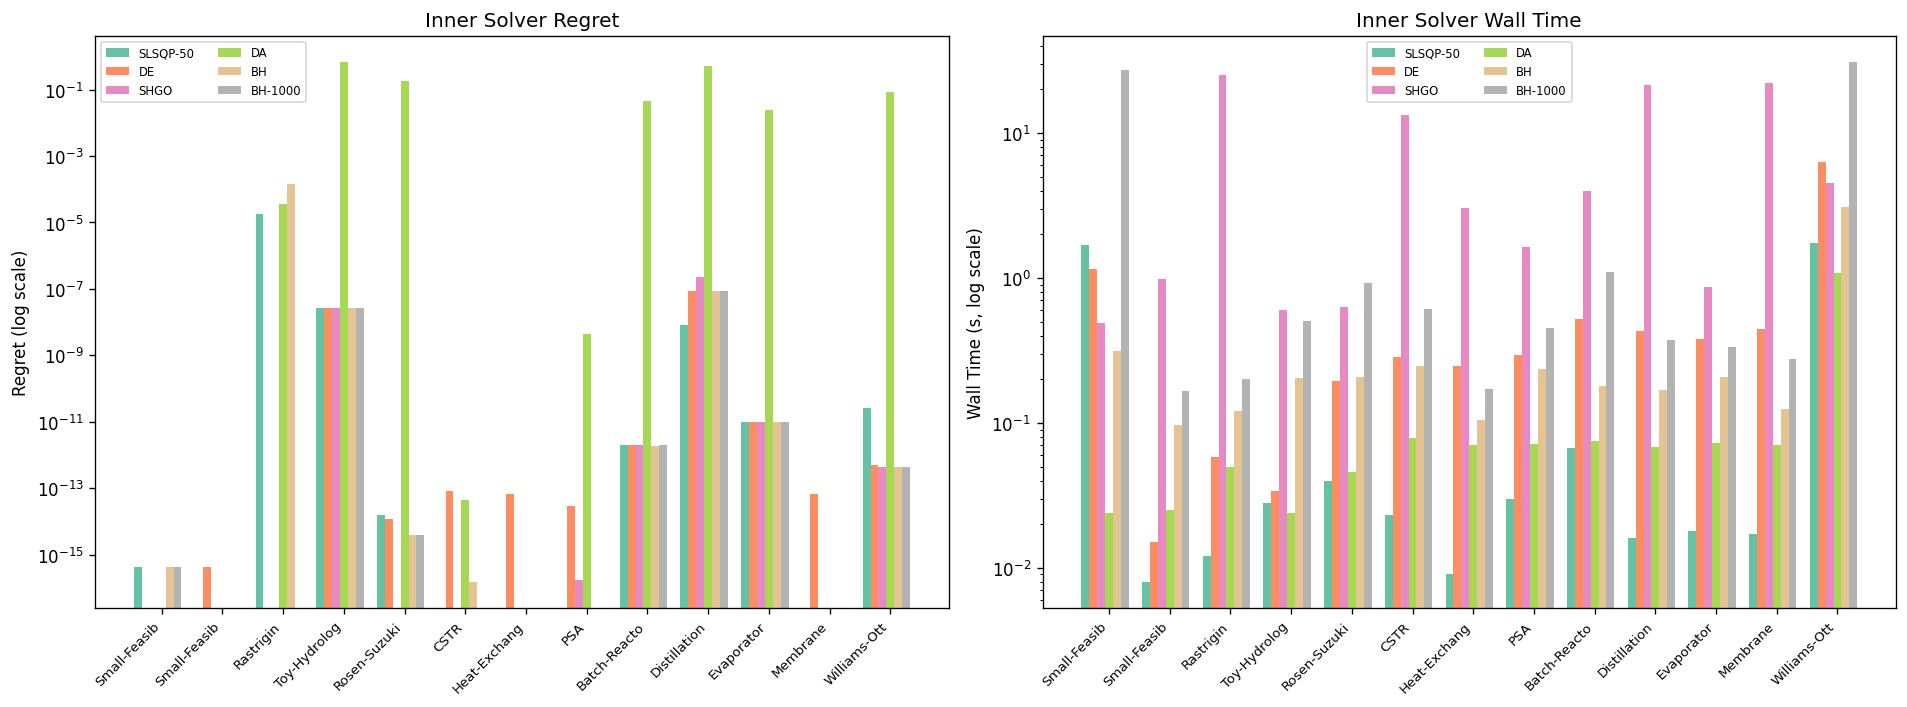

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

all_solvers = SOLVERS + ["BH-1000"]
colors = plt.cm.Set2(np.linspace(0, 1, len(all_solvers)))

# --- Inner regret (log scale) ---
ax = axes[0]
regret_vals = inner_regret.copy()
# Clip zeros to a small value for log scale
regret_plot = regret_vals.replace(0, np.nan)
x = np.arange(len(PROBLEMS))
width = 0.13
for i, solver in enumerate(all_solvers):
    vals = regret_plot[solver].values.astype(float)
    mask = ~np.isnan(vals)
    ax.bar(x[mask] + i * width, vals[mask], width, label=solver, color=colors[i])
ax.set_yscale("log")
ax.set_ylabel("Regret (log scale)")
ax.set_title("Inner Solver Regret")
ax.set_xticks(x + width * len(all_solvers) / 2)
ax.set_xticklabels([p[:12] for p in PROBLEMS], rotation=45, ha="right", fontsize=8)
ax.legend(fontsize=7, ncol=2)

# --- Inner wall time ---
ax = axes[1]
for i, solver in enumerate(all_solvers):
    vals = inner_time[solver].values.astype(float)
    mask = ~np.isnan(vals)
    ax.bar(x[mask] + i * width, vals[mask], width, label=solver, color=colors[i])
ax.set_yscale("log")
ax.set_ylabel("Wall Time (s, log scale)")
ax.set_title("Inner Solver Wall Time")
ax.set_xticks(x + width * len(all_solvers) / 2)
ax.set_xticklabels([p[:12] for p in PROBLEMS], rotation=45, ha="right", fontsize=8)
ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

## 3. Full-Space Solver Comparison

Same solvers applied to the joint [x^WB, x^BB] problem.

In [7]:
# Full-space regret
full_regret = full_all.pivot(index="problem", columns="solver", values="regret")
full_regret = full_regret.reindex(PROBLEMS).reindex(columns=SOLVERS + ["BH-1000"])

print("=== Full-Space Solver Regret ===")
full_regret.map(fmt_regret)

=== Full-Space Solver Regret ===


solver,SLSQP-50,DE,SHGO,DA,BH,BH-1000
problem,,,,,,
Small-Feasible-Region-1,—,7.34e-09,7.34e-09,4.948887,7.34e-09,7.34e-09
Small-Feasible-Region-2,—,3.77e-15,2.22e-16,3.62e-13,6.66e-16,0
Rastrigin,—,0,—,0.000746,9949590570.932951,0
Toy-Hydrology,—,2.74e-08,0.270576,1.000000,2.74e-08,2.74e-08
Rosen-Suzuki,—,1.04e-13,1.34e-12,0.272727,3.07e-15,3.71e-15
CSTR,—,1.53e-13,—,2.02e-12,3.08e-16,0
Heat-Exchanger,—,1.35e-13,—,1.95e-07,0,0
PSA,—,1.66e-13,—,3935147.517922,0,0
Batch-Reactor,—,2.18e-12,1.66e-12,0.043722,1.91e-12,1.89e-12


In [8]:
# Full-space feasibility
full_feas = full_all.pivot(index="problem", columns="solver", values="feasible")
full_feas = full_feas.reindex(PROBLEMS).reindex(columns=SOLVERS + ["BH-1000"])
print("=== Full-Space Solver Feasibility ===")
full_feas.replace({True: "✓", False: "✗", None: "—"})

=== Full-Space Solver Feasibility ===


solver,SLSQP-50,DE,SHGO,DA,BH,BH-1000
problem,,,,,,
Small-Feasible-Region-1,NaN,✓,✓,✗,✓,✓
Small-Feasible-Region-2,NaN,✓,✓,✓,✓,✓
Rastrigin,NaN,✓,✗,✓,✓,✓
Toy-Hydrology,NaN,✓,✗,✗,✓,✓
Rosen-Suzuki,NaN,✓,✓,✗,✓,✓
CSTR,NaN,✓,✗,✓,✓,✓
Heat-Exchanger,NaN,✓,✗,✗,✓,✓
PSA,NaN,✓,✗,✗,✓,✓
Batch-Reactor,NaN,✓,✓,✗,✓,✓


In [9]:
# Full-space wall time
full_time = full_all.pivot(index="problem", columns="solver", values="time_s")
full_time = full_time.reindex(PROBLEMS).reindex(columns=SOLVERS + ["BH-1000"])

print("=== Full-Space Solver Wall Time (seconds) ===")
full_time.round(3)

=== Full-Space Solver Wall Time (seconds) ===


solver,SLSQP-50,DE,SHGO,DA,BH,BH-1000
problem,,,,,,
Small-Feasible-Region-1,NaN,0.140,1.925,0.048,0.284,1.774
Small-Feasible-Region-2,NaN,0.074,9.764,0.053,0.224,0.884
Rastrigin,NaN,0.145,60.003,0.079,0.177,0.672
Toy-Hydrology,NaN,0.173,3.004,0.048,0.290,1.438
Rosen-Suzuki,NaN,1.575,26.115,0.100,0.388,1.909
CSTR,NaN,0.974,60.003,0.148,0.671,5.300
Heat-Exchanger,NaN,0.791,60.004,0.135,0.214,1.680
PSA,NaN,0.806,60.008,0.154,0.677,6.846
Batch-Reactor,NaN,2.201,31.716,0.143,0.392,4.208


### Full-Space: Regret and Time Bar Charts

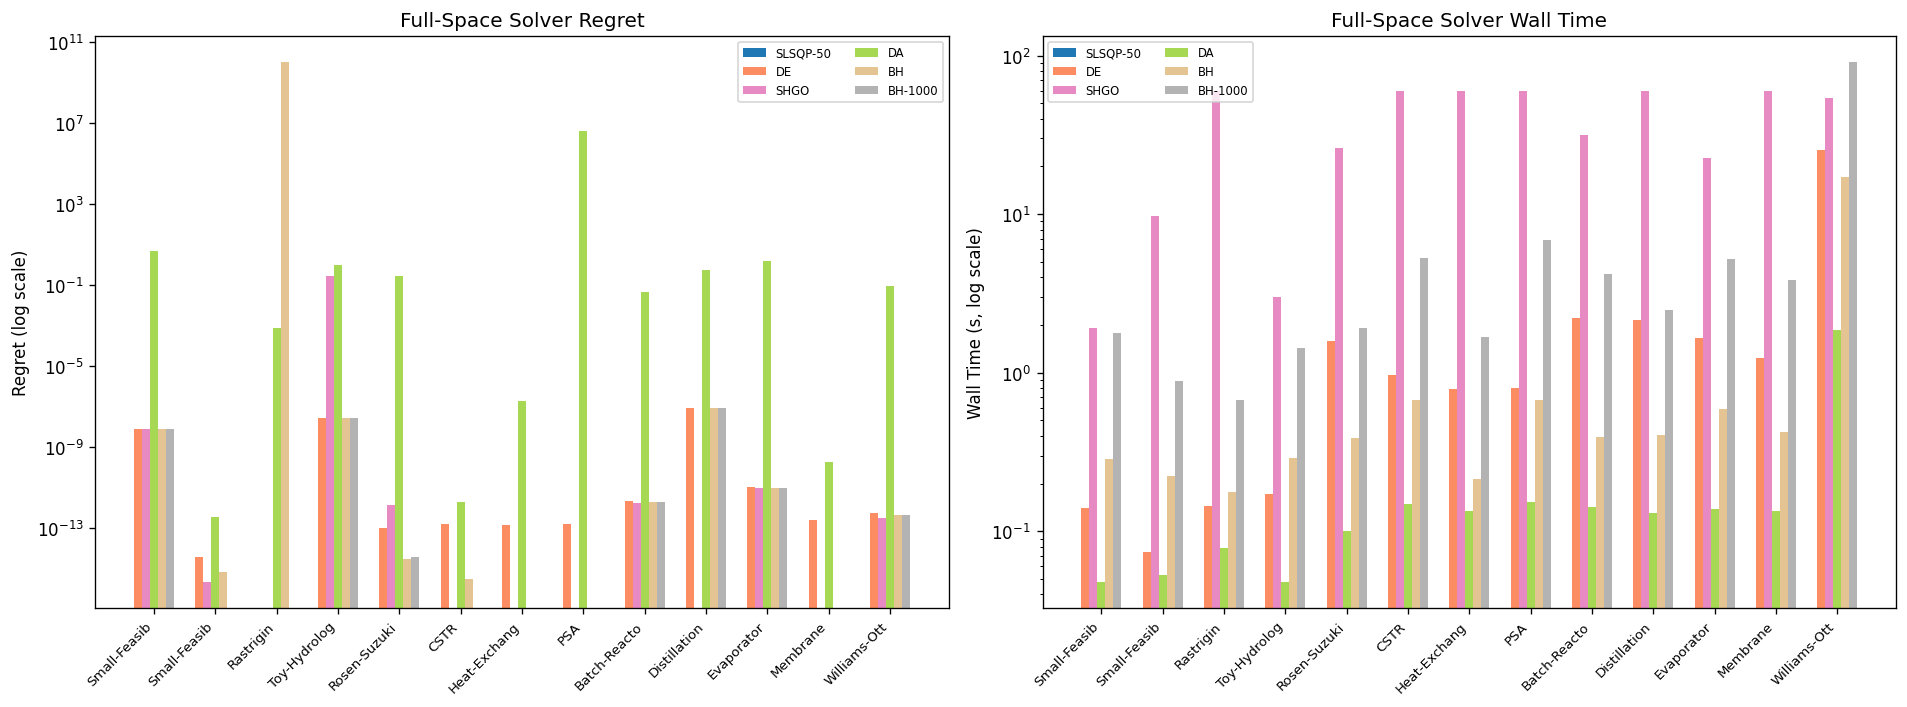

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Full-space regret (log scale) ---
ax = axes[0]
regret_plot = full_regret.replace(0, np.nan)
for i, solver in enumerate(all_solvers):
    vals = regret_plot[solver].values.astype(float)
    mask = ~np.isnan(vals)
    ax.bar(x[mask] + i * width, vals[mask], width, label=solver, color=colors[i])
ax.set_yscale("log")
ax.set_ylabel("Regret (log scale)")
ax.set_title("Full-Space Solver Regret")
ax.set_xticks(x + width * len(all_solvers) / 2)
ax.set_xticklabels([p[:12] for p in PROBLEMS], rotation=45, ha="right", fontsize=8)
ax.legend(fontsize=7, ncol=2)

# --- Full-space wall time ---
ax = axes[1]
for i, solver in enumerate(all_solvers):
    vals = full_time[solver].values.astype(float)
    mask = ~np.isnan(vals)
    ax.bar(x[mask] + i * width, vals[mask], width, label=solver, color=colors[i])
ax.set_yscale("log")
ax.set_ylabel("Wall Time (s, log scale)")
ax.set_title("Full-Space Solver Wall Time")
ax.set_xticks(x + width * len(all_solvers) / 2)
ax.set_xticklabels([p[:12] for p in PROBLEMS], rotation=45, ha="right", fontsize=8)
ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

## 4. BH vs Other Solvers: Win/Loss Summary

Count how many problems each solver "wins" (lowest regret among feasible solutions).

In [11]:
def win_summary(df, label):
    """For each problem, find which solver has the lowest regret (among feasible solutions)."""
    feasible = df[df["feasible"] == True].copy()
    feasible["regret"] = pd.to_numeric(feasible["regret"], errors="coerce")
    feasible = feasible.dropna(subset=["regret"])
    
    winners = feasible.loc[feasible.groupby("problem")["regret"].idxmin()]
    counts = winners["solver"].value_counts().reindex(all_solvers, fill_value=0)
    
    print(f"\n=== {label}: Wins by Solver (lowest regret, feasible only) ===")
    for solver, count in counts.items():
        bar = "█" * count
        print(f"  {solver:>10s}: {count:2d}  {bar}")
    
    return winners[["problem", "solver", "regret"]].set_index("problem")

inner_winners = win_summary(inner_all, "Inner Solver")
full_winners = win_summary(full_all, "Full-Space Solver")


=== Inner Solver: Wins by Solver (lowest regret, feasible only) ===
    SLSQP-50:  7  ███████
          DE:  1  █
        SHGO:  2  ██
          DA:  1  █
          BH:  1  █
     BH-1000:  1  █

=== Full-Space Solver: Wins by Solver (lowest regret, feasible only) ===
    SLSQP-50:  0  
          DE:  2  ██
        SHGO:  2  ██
          DA:  0  
          BH:  5  █████
     BH-1000:  4  ████


## 5. BH-1000 Deep Dive (bh_benchmark.json)

Detailed look at the dedicated Basin-Hopping run with 1000 iterations.

In [12]:
# Build a combined inner vs full-space comparison for BH-1000
bh_compare_rows = []
for prob in PROBLEMS:
    inner = bh_data["inner_results"][prob]
    full = bh_data["full_space_results"][prob]
    bh_compare_rows.append({
        "problem": prob,
        "inner_regret": inner["regret"],
        "full_regret": full["regret"],
        "inner_time_s": inner["time_s"],
        "full_time_s": full["time_s"],
        "inner_feasible": inner["feasible"],
        "full_feasible": full["feasible"],
        "inner_max_g": inner["max_g"],
        "full_max_g": full["max_g"],
    })

bh_compare = pd.DataFrame(bh_compare_rows).set_index("problem")

print("=== BH-1000: Inner vs Full-Space ===")
bh_compare

=== BH-1000: Inner vs Full-Space ===


,inner_regret,full_regret,inner_time_s,full_time_s,inner_feasible,full_feasible,inner_max_g,full_max_g
problem,,,,,,,,
Small-Feasible-Region-1,4.384146e-16,7.343181e-09,27.049,1.774,True,True,5.807396e-10,9.303669e-14
Small-Feasible-Region-2,0.000000e+00,0.000000e+00,0.167,0.884,True,True,-5.000000e-01,-5.000000e-01
Rastrigin,0.000000e+00,0.000000e+00,0.200,0.672,True,True,0.000000e+00,0.000000e+00
Toy-Hydrology,2.737008e-08,2.737009e-08,0.505,1.438,True,True,9.908740e-14,9.331425e-14
Rosen-Suzuki,3.875688e-15,3.714201e-15,0.930,1.909,True,True,6.816769e-14,7.061018e-14
CSTR,0.000000e+00,0.000000e+00,0.607,5.300,True,True,-8.901575e-02,-8.901575e-02
Heat-Exchanger,0.000000e+00,0.000000e+00,0.170,1.680,True,True,-3.155896e+02,-3.761905e+02
PSA,0.000000e+00,0.000000e+00,0.448,6.846,True,True,-3.589602e-02,-3.589602e-02
Batch-Reactor,1.961281e-12,1.894242e-12,1.093,4.208,True,True,3.808065e-14,9.325873e-14


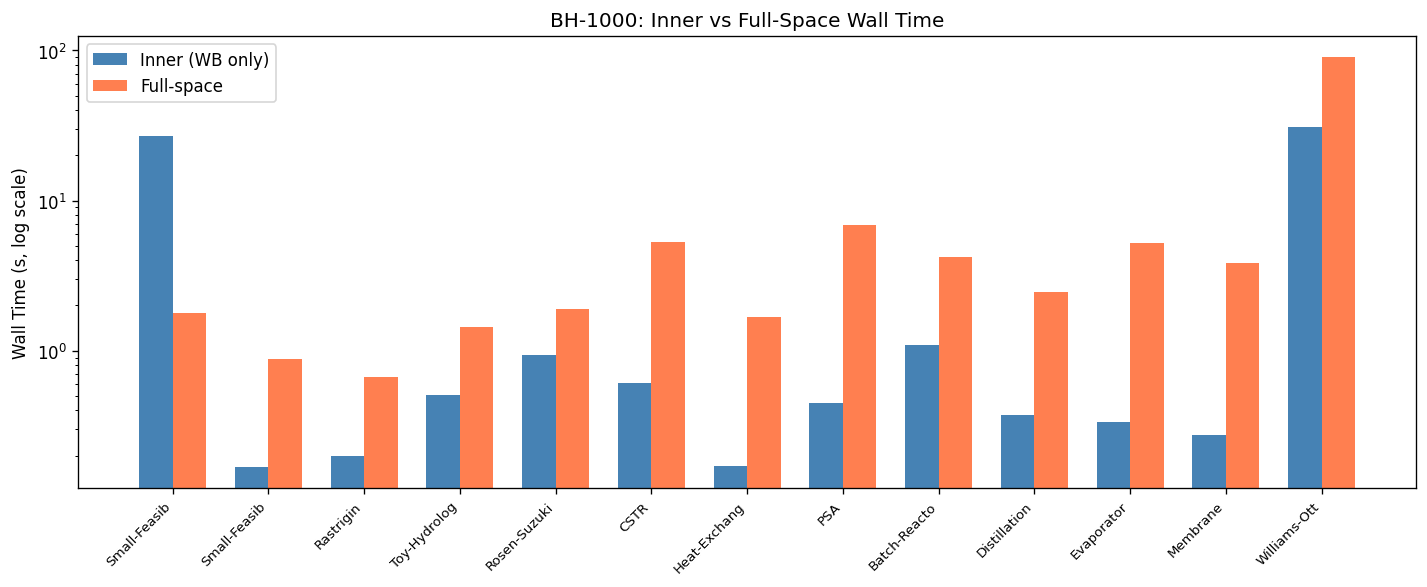

In [13]:
# BH-1000 time comparison: inner vs full-space
fig, ax = plt.subplots(figsize=(12, 5))
x_pos = np.arange(len(PROBLEMS))
bar_w = 0.35
ax.bar(x_pos - bar_w/2, bh_compare["inner_time_s"], bar_w, label="Inner (WB only)", color="steelblue")
ax.bar(x_pos + bar_w/2, bh_compare["full_time_s"], bar_w, label="Full-space", color="coral")
ax.set_yscale("log")
ax.set_ylabel("Wall Time (s, log scale)")
ax.set_title("BH-1000: Inner vs Full-Space Wall Time")
ax.set_xticks(x_pos)
ax.set_xticklabels([p[:12] for p in PROBLEMS], rotation=45, ha="right", fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()

## 6. Solver Failure Analysis

Which solvers fail (infeasible or timed out) on which problems?

In [14]:
def failure_report(df, label):
    """Show problems where solvers are infeasible or timed out."""
    failures = df[(df["feasible"] == False) | (df["timed_out"] == True)].copy()
    if len(failures) == 0:
        print(f"\n{label}: No failures!")
        return
    
    print(f"\n=== {label}: Failures ===")
    for _, row in failures.iterrows():
        reasons = []
        if row.get("feasible") == False:
            reasons.append("infeasible")
        if row.get("timed_out") == True:
            reasons.append("timed out")
        print(f"  {row['problem']:30s}  {row['solver']:>10s}  ({', '.join(reasons)})")

failure_report(inner_all, "Inner Solver")
failure_report(full_all, "Full-Space Solver")


=== Inner Solver: Failures ===
  Small-Feasible-Region-1               SHGO  (infeasible)
  Toy-Hydrology                           DA  (infeasible)
  Rosen-Suzuki                            DA  (infeasible)
  Batch-Reactor                           DA  (infeasible)
  Distillation                          SHGO  (infeasible)
  Distillation                            DA  (infeasible)
  Evaporator                              DA  (infeasible)
  Williams-Otto                           DA  (infeasible)

=== Full-Space Solver: Failures ===
  Small-Feasible-Region-1                 DA  (infeasible)
  Rastrigin                             SHGO  (infeasible, timed out)
  Toy-Hydrology                         SHGO  (infeasible)
  Toy-Hydrology                           DA  (infeasible)
  Rosen-Suzuki                            DA  (infeasible)
  CSTR                                  SHGO  (infeasible, timed out)
  Heat-Exchanger                        SHGO  (infeasible, timed out)
  Heat-Exchan

## 7. Aggregate Statistics

Mean and median regret/time across all 13 problems per solver.

In [15]:
def agg_stats(df, label):
    """Aggregate stats per solver: mean/median regret and time (feasible only)."""
    feasible = df[df["feasible"] == True].copy()
    feasible["regret"] = pd.to_numeric(feasible["regret"], errors="coerce")
    
    stats = feasible.groupby("solver").agg(
        n_feasible=("regret", "count"),
        mean_regret=("regret", "mean"),
        median_regret=("regret", "median"),
        mean_time=("time_s", "mean"),
        median_time=("time_s", "median"),
        total_time=("time_s", "sum"),
    ).reindex(all_solvers)
    
    print(f"\n=== {label}: Aggregate Stats (feasible solutions only) ===")
    return stats

inner_stats = agg_stats(inner_all, "Inner Solver")
inner_stats


=== Inner Solver: Aggregate Stats (feasible solutions only) ===


,n_feasible,mean_regret,median_regret,mean_time,median_time,total_time
solver,,,,,,
SLSQP-50,13,1.369153e-06,1.614870e-14,0.285462,0.023,3.711
DE,12,9.312305e-09,7.400076e-14,0.795923,0.295,10.347
SHGO,11,2.489331e-09,0.000000e+00,7.010364,3.054,77.114
DA,7,5.075916e-06,0.000000e+00,0.055714,0.070,0.390
BH,13,1.094008e-05,4.037175e-15,0.408385,0.204,5.309
BH-1000,13,8.596623e-09,4.384146e-16,4.850692,0.448,63.059


In [16]:
full_stats = agg_stats(full_all, "Full-Space Solver")
full_stats


=== Full-Space Solver: Aggregate Stats (feasible solutions only) ===


,n_feasible,mean_regret,median_regret,mean_time,median_time,total_time
solver,,,,,,
SLSQP-50,NaN,NaN,NaN,NaN,NaN,NaN
DE,13.0,9.158586e-09,2.515124e-13,2.865769,0.9740,37.255
SHGO,6.0,1.226235e-09,1.502443e-12,24.407167,24.4275,146.443
DA,4.0,1.865175e-04,9.249738e-11,0.103750,0.1070,0.415
BH,13.0,7.653531e+08,4.355024e-13,1.682692,0.3920,21.875
BH-1000,13.0,9.184229e-09,3.714201e-15,9.796077,2.4760,127.349


## 8. Regret Heatmaps

Log-scale regret heatmap across all problems and solvers.

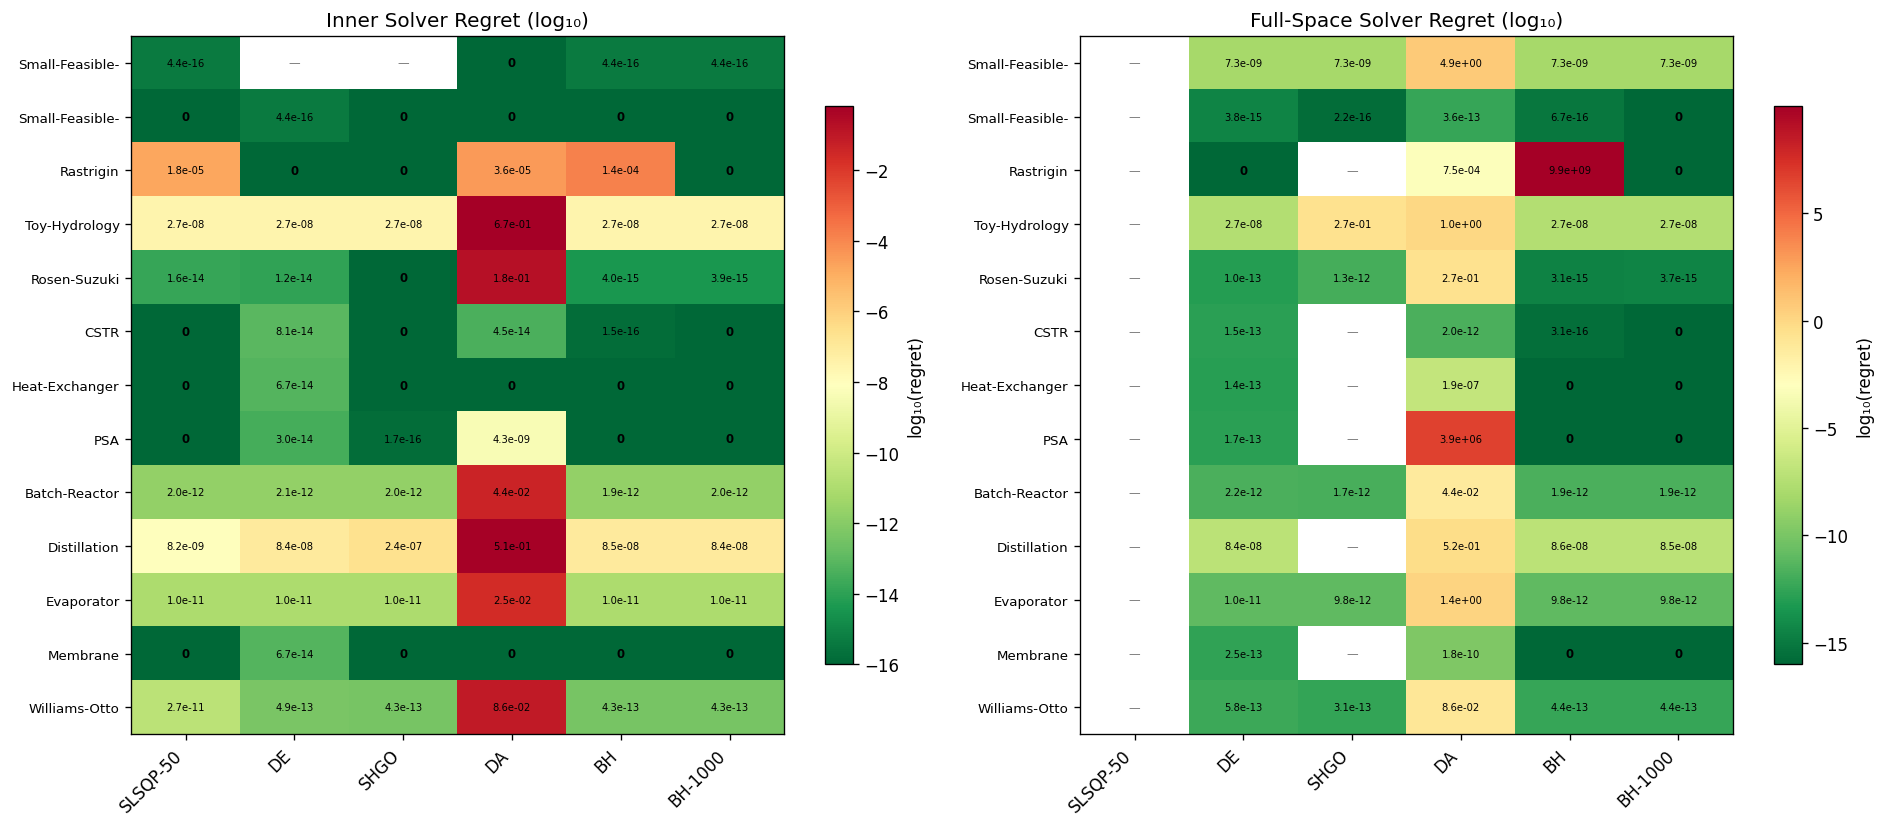

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, regret_df, title in [
    (axes[0], inner_regret, "Inner Solver Regret (log₁₀)"),
    (axes[1], full_regret, "Full-Space Solver Regret (log₁₀)"),
]:
    # Replace 0 with a tiny value for log, NaN stays NaN
    data = regret_df.astype(float).replace(0, 1e-16)
    log_data = np.log10(data)
    
    im = ax.imshow(log_data.values, aspect="auto", cmap="RdYlGn_r", interpolation="nearest")
    ax.set_xticks(range(len(all_solvers)))
    ax.set_xticklabels(all_solvers, rotation=45, ha="right")
    ax.set_yticks(range(len(PROBLEMS)))
    ax.set_yticklabels([p[:15] for p in PROBLEMS], fontsize=8)
    ax.set_title(title)
    
    # Annotate cells
    for i in range(len(PROBLEMS)):
        for j in range(len(all_solvers)):
            val = regret_df.iloc[i, j]
            if pd.isna(val):
                ax.text(j, i, "—", ha="center", va="center", fontsize=7, color="gray")
            elif val == 0:
                ax.text(j, i, "0", ha="center", va="center", fontsize=7, fontweight="bold")
            else:
                ax.text(j, i, f"{val:.1e}", ha="center", va="center", fontsize=6)
    
    plt.colorbar(im, ax=ax, shrink=0.8, label="log₁₀(regret)")

plt.tight_layout()
plt.show()

## 9. BH Configuration Reference

Basin-Hopping configuration used in `bh_benchmark.json`.

In [18]:
print("BH Benchmark Configuration:")
for k, v in bh_data["config"].items():
    print(f"  {k}: {v}")
print(f"  timeout_s: {bh_data['timeout_s']}")

BH Benchmark Configuration:
  niter: 1000
  T: 100.0
  stepsize: max_range / 2 (per-problem adaptive)
  local_minimizer: SLSQP
  local_maxiter: 500
  local_ftol: 1e-14
  take_step: BoundedStep (uniform perturbation clipped to bounds)
  uses_gradients: Yes (J_grad_x_wb, g_grad_x_wb) for inner; No for full-space
  constraint_handling: Via SLSQP local minimizer (dict-style ineq constraints)
  timeout_s: 300


## 10. Solver Selection Rationale

Basin-Hopping was selected as the unified global solver for both the inner-loop and full-space benchmarks. While specialized solvers such as multistart SLSQP or differential evolution may win on individual problems, they lack consistency: SHGO and dual annealing frequently return infeasible solutions, and multistart SLSQP cannot be applied to the derivative-free full-space problem at all. Basin-Hopping, by contrast, finds feasible solutions on all 13 problems in both contexts and reaches the global optimum to within machine tolerance in nearly every case. The apparent accuracy gap between Basin-Hopping and other solvers is negligible in practice—regret differences are on the order of 1e-14 to 1e-8, well below any meaningful engineering threshold. Because Basin-Hopping wraps a local SLSQP minimizer inside a global exploration loop, it inherits gradient-based precision on the inner problem while adding the global search guarantees needed for the full-space benchmark. This combination of universal feasibility, near-exact optimality, and applicability to both problem contexts makes it the most defensible single-solver choice for establishing ground-truth optima across the benchmark suite.